# **🎬 Molecular Movies: A Student Guide to Molecular Dynamics**
Welcome, Scientists! Today, you are not just running code—you are becoming architects of the microscopic world. We are going to simulate how proteins move, fold, and misfold. To do this, we use GROMACS, a powerful tool that uses the laws of physics to predict protein behavior.

To get started, we will use Lysozyme—a classic "model protein" in biology known for its antibacterial properties. Because it is small, robust, and well-studied, it is the perfect "training dummy" for mastering the complex GROMACS simulation pipeline. By the end of this lab, you will have successfully simulated the motion of Lysozyme in water!

Why do we need this code? Think of Google Colab as a "rented" computer in the cloud. It doesn't come with GROMACS pre-installed, so we must build our laboratory from scratch every time we open this notebook. We use ! to command the underlying Linux system to install the software for us.

# 🟢 Part I: Environment Setup

Run this part once at the start of your session to configure the cloud virtual machine. Why do we need this code? Think of Google Colab as a "rented" computer in the cloud. It doesn't come with GROMACS pre-installed, so we must build our laboratory from scratch every time we open this notebook. We use ! to command the underlying Linux system to install the software for us.

**Mentor's Note**: Don't worry about the warnings you see during installation; they are just "system noise." As long as you don't see an "ERROR," our virtual lab is ready for action!

In [ ]:
# Install GROMACS
!apt-get update -qq
!apt-get install -y -qq gromacs

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Preconfiguring packages ...
Selecting previously unselected package sse4.2-support.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../0-sse4.2-support_6_amd64.deb ...
Unpacking sse4.2-support (6) ...
Selecting previously unselected package fonts-mathjax.
Preparing to unpack .../1-fonts-mathjax_2.7.9+dfsg-1_all.deb ...
Unpacking fonts-mathjax (2.7.9+dfsg-1) ...
Selecting previously unselected package libfftw3-double3:amd64.
Preparing to unpack .../2-libfftw3-double3_3.3.8-2ubuntu8_amd64.deb ...
Unpacking libfftw3-double3:amd64 (3.3.8-2ubuntu8) ...
Selecting previously unselected package libfftw3-single3:amd64.
Preparing to unpack .../3-libfftw3-single3_3.3.8-2ubuntu8_amd64.deb ...
Unpacking libfftw3-single3:amd64 (3.3.8-2ubuntu8) ...
Selecting previously 

In [ ]:
# Verify installations
!gmx --version

                 :-) GROMACS - gmx, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teem

In [ ]:
# Mount Google Drive for persistent storage
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Creat a project folder in your Drive and set it as working directory
import os
project_dir = '/content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation'
if not os.path.exists(project_dir):
  os.makedirs(project_dir)
%cd {project_dir}
print(f"Working directory set to: {os.getcwd()}")

/content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation
Working directory set to: /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation


## Setting up the T4 GPU Runtime
---

Before running any code cells, you must ensure Google Colab is configured to use an NVIDIA T4 GPU. By default, Colab sessions run on standard CPU instances, which will cause GROMACS simulations to run extremely slowly or fail.

---
Here is the step-by-step instructions:


1.   Open Runtime Settings:
    
    In the top navigation menu, click **Runtime** then **Change runtime type**


2.   Select Hardware Accelerator:

    Under Hardware accelerator, select T4 GPU from the drowdown menu

3.   Save and Connect:

    Click Save, Then look at the top-right corner of the notebook to verify that connection status displays RAM Disk alongside T4

4. **Need Help?**
   If you experience any trouble setting up the runtime, feel free to reach out to us (**Nabin** and **Kushma**).

---



## Download & Extract Pre-compiled GROMACS GPU Binary

In [ ]:
# Running this will download setup script.sh from GitHub Release
!wget --show-progress "https://github.com/n-oli/gromacs-colab-cuda/releases/download/v2026.3-colabT4.1/script.sh"


--2026-08-11 19:55:35--  https://github.com/n-oli/gromacs-colab-cuda/releases/download/v2026.3-colabT4.1/script.sh
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1318983877/0014217b-d91c-4b2e-9662-83b21c889a04?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-08-11T20%3A33%3A25Z&rscd=attachment%3B+filename%3Dscript.sh&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-08-11T19%3A33%3A02Z&ske=2026-08-11T20%3A33%3A25Z&sks=b&skv=2018-11-09&sig=Vpi1cPnk9Z5wFfhji2UODj%2F37v2V4of%2BIW0AN1Mpg5I%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4NjQ3ODQzNSwibmJmIjoxNzg2NDc4MTM1LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjd

### After running above cell you should have output similar to this

---


HTTP request sent, awaiting response... 200 OK
Length: 292 [application/octet-stream]
Saving to: ‘script.sh’

script.sh           100%[===================>]     292  --.-KB/s    in 0s      

2026-08-01 19:08:52 (8.64 MB/s) - ‘script.sh’ saved [292/292]

---

In [ ]:
# Here we will run the downloaded bash script to download our GROMACS GPU Binary
! bash script.sh

--2026-08-11 19:55:38--  https://github.com/n-oli/gromacs-colab-cuda/releases/download/v2026.3-colabT4.1/gromacs_cuda_build.tar.gz
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1318983877/9463dc45-b30e-4efd-9c10-1676102d333c?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-08-11T20%3A32%3A51Z&rscd=attachment%3B+filename%3Dgromacs_cuda_build.tar.gz&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-08-11T19%3A31%3A54Z&ske=2026-08-11T20%3A32%3A51Z&sks=b&skv=2018-11-09&sig=5eX%2B5OPpyiCNbaTq5uZWCV0hF7jL5xr4GxnSJn%2BkPg8%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4NjQ3OTkzOCwibmJmIjoxNzg2NDc4MTM4LCJwY

### After running above cell you should have output similar to this


---
HTTP request sent, awaiting response... 200 OK
Length: 92 [application/octet-stream]
Saving to: ‘SHA256SUMS.txt’

SHA256SUMS.txt      100%[===================>]      92  --.-KB/s    in 0s      

2026-08-01 19:09:15 (2.93 MB/s) - ‘SHA256SUMS.txt’ saved [92/92]

gromacs_cuda_build.tar.gz: OK

---




## Now you have downloaded all the Binaries, Your will set system Path and Verify installations

In [ ]:
# This will add GROMACS Binary path to this colab session
import os
os.environ['PATH'] += ':/usr/local/gromacs/bin'

In [ ]:
# Run this to veirfy GROMACS installation
! gmx --version

                         :-) GROMACS - gmx, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx --version

GROMACS version:     2026.3
Precision:           mixed
Memory model:        64 bit
MPI library:         thread_mpi
MPI version:         built in
OpenMP support:      enabled (GMX_OPENMP_MAX_THREADS = 128)
GPU support:         CUDA
NBNxM GPU setup:     super-cluster 2x2x2 / cluster 8 (cluster-pair splitting on)
SIMD instructions:   AVX_512
CPU FFT library:     fftw-3.3.10-sse2-avx-avx2-avx2_128-avx512
GPU FFT library:     cuFFT
Multi-GPU FFT:       none
RDTSCP:              enabled
TNG support:         enabled
Hwloc support:       disabled
Tracing support:     disabled
Colvars support:     enabled (version 2025-10-13)
CP2K support:        disabled
Torch support:       disabled
Plumed support:      enabled
C compiler:          /usr/bin/cc GNU 11.4.0
C compiler flags:    -fexcess-precision=fast -funroll-all-

In [ ]:
# Mount Google Drive for backup storage.
from google.colab import drive
from pathlib import Path
import os

drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_DIR)

print(f"Persistent working directory: {PROJECT_DIR}")


Mounted at /content/drive
Persistent working directory: /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation


## Finally you are Ready for Simulation

Before running our own simulation, this will walk through the GROMACS tutorial inspired by this website [Lysozyme 1AKI Tutorial](http://www.mdtutorials.com/gmx/lysozyme/index.html)

---

Just to recap from Thursday:

---

The introductory slide emphasized that protein function depends on three-dimensional structure and motion. Amino-acid sequence constrains the structures a protein can adopt, while bonded geometry, electrostatics, van der Waals interactions, hydrogen bonding, solvent, and the hydrophobic effect shape its conformational behavior.

A PDB file is a snapshot. Molecular dynamics turns that snapshot into a time-ordered series of coordinates:

1. A force field assigns mathematical functions and parameters for bonds, angles, dihedrals, electrostatics, and van der Waals interactions.

2. GROMACS calculates the force on every atom from the gradient of the potential energy.

3. A numerical integrator advances positions and velocities by a very small time step.

4. Repeating this cycle millions of times produces a trajectory, which is the molecular movie.

# 🔵 Part II: Prepare the Protein

We must download the protein structure file with which we will be working. For this tutorial, we will utilize hen egg white lysozyme (PDB code 1AKI). Go to the RCSB website (https://www.rcsb.org) and download the PDB text for the crystal structure. Don't forget to save this PDB file in the working directory.

Once you have downloaded the structure, you can visualize the structure using a viewing program such as VMD, Chimera, PyMOL, etc. Once you've had a look at the molecule, you are going to want to strip out the crystal waters. To delete the water molecules (residue "HOH" in the PDB file), either use a plain text editor like vi, emacs (Linux/Mac), or Notepad (Windows). Do not use word processing software! Alternatively, you can use grep to delete these lines very easily:

In [ ]:
!grep -v HOH 1AKI-2.pdb > 1AKI_clean.pdb

Note that such a procedure is not universally appropriate (e.g., the case of a tightly bound or otherwise functional active-site water molecule). For our intentions here, we do not need crystal water.

Always check your .pdb file for entries listed under the comment MISSING, as these entries indicate either atoms or whole residues that are not present in the crystal structure. Terminal regions may be absent, and may not present a problem for dynamics. Incomplete internal sequences or any amino acid residues that have missing atoms will cause pdb2gmx to fail. These missing atoms/residues must be modeled in using other software packages. Also note that pdb2gmx is not magic. It cannot generate topologies for arbitrary molecules, just the residues defined by the force field (in the *.rtp files - generally proteins, nucleic acids, and a very finite amount of cofactors, like NAD(H) and ATP).

Now that the crystal waters are gone and we have verified that all the necessary atoms are present, the PDB file should contain only protein atoms, and is ready to be input into the first GROMACS module, pdb2gmx. The purpose of pdb2gmx is to generate three files:

The topology for the molecule. A position restraint file. A post-processed structure file. The topology (topol.top by default) contains all the information necessary to define the molecule within a simulation. This information includes nonbonded parameters (atom types and charges) as well as bonded parameters (bonds, angles, and dihedrals). We will take a more detailed look at the topology once it has been generated.

Execute pdb2gmx by issuing the following command, and you will be prompted to choose a force field. The force field will contain the information that will be written to the topology. This is a very important choice! You should always read thoroughly about each force field and decide which is most applicable to your situation. For this tutorial, we will use the all-atom OPLS force field, so type 15 at the command prompt, followed by 'Enter'.

There are many other options that can be passed to pdb2gmx. Some commonly used ones are listed here:

-ignh: Ignore H atoms in the PDB file; especially useful for NMR structures. Otherwise, if H atoms are present, they must be in the named exactly how the force fields in GROMACS expect them to be. Different conventions exist, so dealing with H atoms can occasionally be a headache! If you need to preserve the initial H coordinates, but renaming is required, then the Linux sed command is your friend.

-ter: Interactively assign charge states for N- and C-termini.

-inter: Interactively assign charge states for Glu, Asp, Lys, Arg, and His; choose which Cys are involved in disulfide bonds.


In [ ]:
!gmx pdb2gmx -f 1AKI_clean.pdb -o 1AKI_processed.gro -water spce -ignh

             :-) GROMACS - gmx pdb2gmx, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

Choose the OPLS-AA/L all-atom force field.

You have now generated three new files: 1AKI_processed.gro, topol.top, and posre.itp. 1AKI_processed.gro is a GROMACS-formatted structure file that contains all the atoms defined within the force field (i.e., H atoms have been added to the amino acids in the protein). The topol.top file is the system topology (more on this in a minute). The posre.itp file contains information used to restrain the positions of heavy atoms (more on this later).

One final note: many users assume that a .gro file is mandatory. This is not true. GROMACS can handle many different file formats, with .gro simply being the default for commands that write coordinate files. It is a very compact format, but it has limited precision. If you prefer to use, for instance, PDB format, all you need to do is to specify an appropriate file name with .pdb extension as your output. The purpose of pdb2gmx is to produce a force field-compliant topology; the output structure is largely a side effect of this purpose and is intended for user convenience. The format can be just about anything you like (see the GROMACS manual for different formats).

Let's look at what is in the output topology (topol.top). Again, using a plain text editor, inspect its contents. After several comment lines (preceded by ;), you will find the following:                       

`#include "oplsaa.ff/forcefield.itp"`

This line calls the parameters within the OPLS-AA force field. It is at the beginning of the file, indicating that all subsequent parameters are derived from this force field. The next important line is `[ moleculetype ]`, below which you will find

Screenshot 2026-06-03 at 3.38.51 PM.png

The name "Protein_A" defines the molecule name, based on the fact that the protein was labeled as chain A in the PDB file. There are 3 exclusions for bonded neighbors. More information on exclusions can be found in the GROMACS manual; a discussion of this information is beyond the scope of this tutorial.

The next section defines the `[ atoms ]` in the protein. The information is presented as columns:


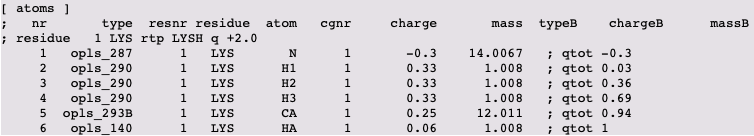

The interpretation of this information is as follows:

nr: Atom number
type: Atom type
resnr: Amino acid residue number
residue: The amino acid residue name
Note that this residue was "LYS" in the PDB file; the use of .rtp entry "LYSH" indicates that the residue is protonated (the predominant state at neutral pH).
atom: Atom name
cgnr: Charge group number
Charge groups define units of integer charge; they aid in speeding up calculations
charge: Self-explanatory
The "qtot" descriptor is a running total of the charge on the molecule
mass: Also self-explanatory
typeB, chargeB, massB: Used for free energy perturbation (not discussed here)
Subsequent sections include `[ bonds ]`, `[ pairs ]`, `[ angles ]`, and `[ dihedrals ]`. Some of these sections are self-explanatory (bonds, angles, and dihedrals). The parameters and function types associated with these sections are elaborated on in Chapter 5 of the GROMACS manual. Special 1-4 interactions are included under "pairs" (section 5.3.4 of the GROMACS manual).



The remainder of the file involves defining a few other useful/necessary topologies, starting with position restraints. The "posre.itp" file was generated by pdb2gmx; it defines a force constant used to keep atoms in place during equilibration (more on this later).


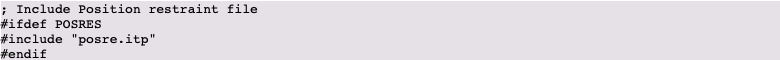

This ends the "Protein_A" moleculetype definition. The remainder of the topology file is dedicated to defining other molecules and providing system-level descriptions. The next moleculetype (by default) is the solvent, in this case SPC/E water. Other typical choices for water include SPC, TIP3P, and TIP4P. We chose this by passing "-water spce" to pdb2gmx. For an excellent summary of the many different water models, click here, but be aware that not all of these models are present within GROMACS.

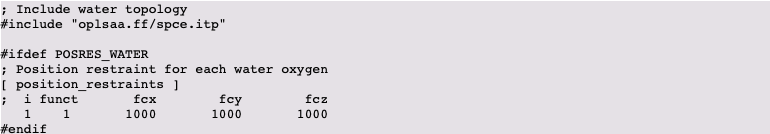

As you can see, water can also be position-restrained, using a force constant ($k_{pr}$) of 1000 kJ mol$^{-1}$ nm$^{-2}$.

Ion parameters are included next:

Screenshot 2026-06-03 at 4.04.04 PM.png

Finally come system-level definitions. The `[ system ]` directive gives the name of the system that will be written to output files during the simulation. The `[ molecules ]` directive lists all of the molecules in the system.

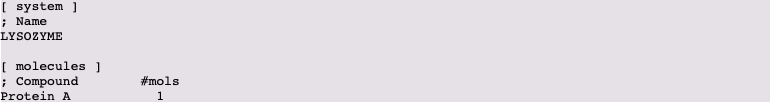

A few key notes about the `[ molecules ]` directive:

The order of the listed molecules must exactly match the order of the molecules in the coordinate (in this case, .gro) file.
The names listed must match the `[ moleculetype ]` name for each species, not residue names or anything else.
If you fail to satisfy these concrete requirements at any time, you will get fatal errors from grompp (discussed later) about mismatched names, molecules not being found, or a number of others.

Now that we have examined the contents of a topology file, we can continue building our system.

# 🟡 Part III: Building the "Aquarium"

Now that you are familiar with the contents of the GROMACS topology, it is time to continue building our system. In this example, we are going to be simulating a simple aqueous system. It is possible to simulate proteins and other molecules in different solvents, provided that good parameters are available for all species involved.

There are two steps to defining the box and filling it with solvent:

Define the box dimensions using the editconf module.
Fill the box with water using the solvate module (formerly called genbox).
You are now presented with a choice as to how to treat the unit cell. For the purpose of this tutorial, we will use a simple cubic box as the unit cell. As you become more comfortable with periodic boundary conditions and box types, I highly recommend the rhombic dodecahedron, as its volume is ~71% of the cubic box of the same periodic distance, thus saving on the number of water molecules that need to be added to solvate the protein.

Let's define the box using editconf:

In [ ]:
!gmx editconf -f 1AKI_processed.gro -o 1AKI_box.gro -c -d 1.0 -bt cubic

             :-) GROMACS - gmx editconf, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff           

The above command centers the protein in the box (-c), and places it at least 1.0 nm from the box edge (-d 1.0). The box type is defined as a cube (-bt cubic). The distance to the edge of the box is an important parameter. Since we will be using periodic boundary conditions, we must satisfy the minimum image convention. That is, a protein should never see its periodic image, otherwise the forces calculated will be spurious. Specifying a solute-box distance of 1.0 nm will mean that there are at least 2.0 nm between any two periodic images of a protein. This distance will be sufficient for just about any cutoff scheme commonly used in simulations.

Now that we have defined a box, we can fill it with solvent (water). Solvation is accomplished using solvate:

In [ ]:
!gmx solvate -cp 1AKI_box.gro -cs spc216.gro -o 1AKI_solv.gro -p topol.top

             :-) GROMACS - gmx solvate, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

The configuration of the protein (-cp) is contained in the output of the previous editconf step, and the configuration of the solvent (-cs) is part of the standard GROMACS installation. We are using spc216.gro, which is a generic equilibrated 3-point solvent model. You can use spc216.gro as the solvent configuration for SPC, SPC/E, or TIP3P water, since they are all three-point water models. The output is called 1AKI_solv.gro, and we tell solvate the name of the topology file (topol.top) so it can be modified. Note the changes to the `[ molecules ]` directive of topol.top:

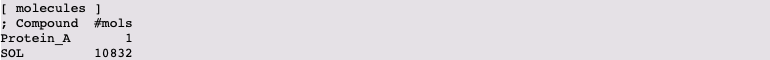

What solvate has done is keep track of how many water molecules it has added, which it then writes to your topology to reflect the changes that have been made. Note that if you use any other (non-water) solvent, solvate will not make these changes to your topology! Its compatibility with updating water molecules is hard-coded.

We now have a solvated system that contains a charged protein. The output of pdb2gmx told us that the protein has a net charge of +8e (based on its amino acid composition). If you missed this information in the pdb2gmx output, look at the last line of your `[ atoms ]` directive in topol.top; it should read (in part) "qtot 8." Since life does not exist at a net charge, we must add ions to our system.

The tool for adding ions within GROMACS is called genion. What genion does is read through the topology and replace water molecules with the ions that the user specifies. The input is called a run input file, which has an extension of .tpr; this file is produced by the GROMACS grompp module (GROMACS pre-processor), which will also be used later when we run our first simulation. What grompp does is process the coordinate file and topology (which describes the molecules) to generate an atomic-level input (.tpr). The .tpr file contains all the parameters for all of the atoms in the system.

To produce a .tpr file with grompp, we will need an additional input file, with the extension .mdp (molecular dynamics parameter file); grompp will assemble the parameters specified in the .mdp file with the coordinates and topology information to generate a .tpr file.

An .mdp file is normally used to run energy minimization or an MD simulation, but in this case is simply used to generate an atomic description of the system. An example ions.mdp file (the one we will use) is already uploaded to the working directory.

In reality, the .mdp file used at this step can contain any legitimate combination of parameters. I typically use an energy-minimization script, because they are very basic and do not involve any complicated parameter combinations. Please note that the files provided with this tutorial are intended only for use with the OPLS-AA force field. Settings, particularly nonbonded interaction settings, will be different for other force fields.

Assemble your .tpr file with the following:

In [ ]:
!gmx grompp -f ions.mdp -c 1AKI_solv.gro -p topol.top -o ions.tpr -maxwarn 3

              :-) GROMACS - gmx grompp, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

Now we have an atomic-level description of our system in the binary file ions.tpr. We will pass this file to genion:

In [ ]:
!gmx genion -s ions.tpr -o 1AKI_solv_ions.gro -p topol.top -pname NA -nname CL -neutral -conc 0.15

              :-) GROMACS - gmx genion, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

When prompted, choose group 13 "SOL" for embedding ions. You do not want to replace parts of your protein with ions.

In the genion command, we provide the structure/state file (-s) as input, generate a .gro file as output (-o), process the topology (-p) to reflect the removal of water molecules and addition of ions, define positive and negative ion names (-pname and -nname, respectively), and tell genion to add the ions necessary to neutralize the net charge on the protein by adding the correct number of negative ions (-neutral, which in this case will add 8 Cl- ions to offset the +8 charge on the protein). You can also use genion to add a specified concentration of ions in addition to simply neutralizing the system by specifying the -neutral and -conc options in conjunction. Refer to the genion man page for information on how to use these options.

The names of the ions specified with -pname and -nname were force field-specific in previous versions of GROMACS, but were standardized in version 4.5. The specified ion names are always the elemental symbol in all capital letters, which is the [ moleculetype ] name that is then written to the topology. Residue or atom names may or may not append the sign of the charge (+/-), depending on the force field. Do not use atom or residue names in the genion command, or you will encounter errors in subsequent steps.

Your `[ molecules ]` directive should now look like:

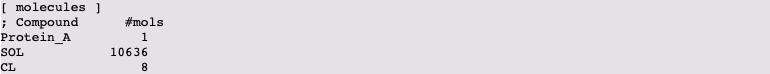

Now you can visualize your "aquarium" by VMD:

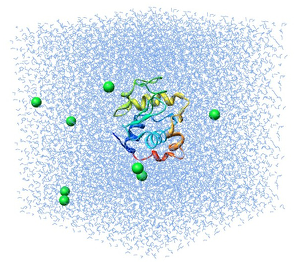

# 🔴 Part IV: Relaxation of System

**Energy Minimization**

The solvated, electroneutral system is now assembled. Before we can begin dynamics, we must ensure that the system has no steric clashes or inappropriate geometry. The structure is relaxed through a process called energy minimization (EM).

The process for EM is much like the addition of ions. We are once again going to use grompp to assemble the structure, topology, and simulation parameters into a binary input file (.tpr), but this time, instead of passing the .tpr to genion, we will run the energy minimization through the GROMACS MD engine, mdrun.

Assemble the binary input using grompp using this input parameter file:**bold text**

In [ ]:
!gmx grompp -f minimi.mdp -c 1AKI_solv_ions.gro -p topol.top -o em.tpr

              :-) GROMACS - gmx grompp, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

Make sure you have been updating your topol.top file when running genbox and genion, or else you will get lots of nasty error messages ("number of coordinates in coordinate file does not match topology," etc).

We are now ready to invoke mdrun to carry out the EM:

In [ ]:
!gmx mdrun -v -deffnm em

              :-) GROMACS - gmx mdrun, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            T

The -v flag is for the impatient: it makes mdrun verbose, such that it prints its progress to the screen at every step. The -deffnm flag will define the file names of the input and output. So, if you did not name your grompp output "em.tpr," you will have to explicitly specify its name with the mdrun -s flag. In our case, we will get the following files:

* em.log: ASCII-text log file of the EM process
* em.edr: Binary energy file
* em.trr: Binary full-precision trajectory
* em.gro: Energy-minimized structure

The mdrun program will also print the final output of energy minimization (maximum force, and the potential energy of the system) to both the .log file and the terminal.

There are two very important factors to evaluate to determine if EM was successful. The first is the potential energy (printed at the end of the EM process, even without -v). Epot should be negative, and (for a simple protein in water) on the order of 105-106, depending on the system size and number of water molecules. The second important feature is the maximum force, Fmax, the target for which was set in minim.mdp - "emtol = 1000.0" - indicating a target Fmax of no greater than 1000 kJ mol$^{-1}$ nm$^{-1}$. It is possible to arrive at a reasonable Epot with Fmax > emtol. If this happens, your system may not be stable enough for simulation. Evaluate why it may be happening, and perhaps change your minimization parameters (integrator, emstep, etc).

Let's do a bit of analysis. The em.edr file contains all of the energy terms that GROMACS collects during EM. You can analyze any .edr file using the GROMACS energy module: (at the prompt, type "11 0" to select Potential (11); zero (0) terminates input. You will be shown the average of Epot, and a file called "potential.xvg" will be written.)

In [ ]:
!gmx energy -f em.edr -o potential.xvg

              :-) GROMACS - gmx energy, 2021.4-Ubuntu-2021.4-2 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            

Plot the data to make sure it is a steady convergence.

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_714/3967758615.py:4: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv('potential.xvg', sep='\s+', skiprows=24, header=None)


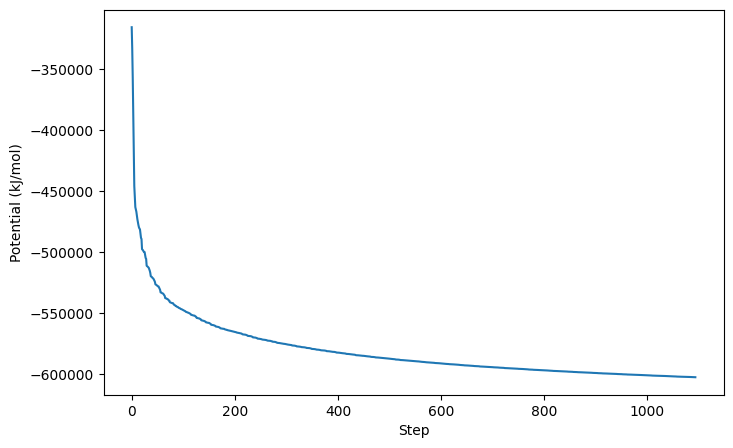

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('potential.xvg', sep='\s+', skiprows=24, header=None)

plt.figure(figsize=(8, 5))
plt.plot(data[0], data[1])
#plt.title("")
plt.xlabel("Step")
plt.ylabel("Potential (kJ/mol)")
plt.grid(False)
plt.show()

**NVT Equilibration**

EM ensured that we have a reasonable starting structure, in terms of geometry and solvent orientation. To begin real dynamics, we must equilibrate the solvent and ions around the protein. If we were to attempt unrestrained dynamics at this point, the system may collapse. The reason is that the solvent is mostly optimized within itself, and not necessarily with the solute. It needs to be brought to the temperature we wish to simulate and establish the proper orientation about the solute (the protein). After we arrive at the correct temperature (based on kinetic energies), we will apply pressure to the system until it reaches the proper density.

Remember that posre.itp file that pdb2gmx generated a long time ago? We're going to use it now. The purpose of posre.itp is to apply a position restraining force on the heavy atoms of the protein (anything that is not a hydrogen). Movement is permitted, but only after overcoming a substantial energy penalty. The utility of position restraints is that they allow us to equilibrate our solvent around our protein, without the added variable of structural changes in the protein. The origin of the position restraints (the coordinates at which the restraint potential is zero) is provided via a coordinate file passed to the -r option of grompp.

Equilibration is often conducted in two phases. The first phase is conducted under an NVT ensemble (constant Number of particles, Volume, and Temperature). This ensemble is also referred to as "isothermal-isochoric" or "canonical." The timeframe for such a procedure is dependent upon the contents of the system, but in NVT, the temperature of the system should reach a plateau at the desired value. If the temperature has not yet stabilized, additional time will be required. Typically, 50-100 ps should suffice, and we will conduct a 100-ps NVT equilibration for this exercise. Depending on your machine, this may take a while (just under an hour if run in parallel on 16 cores or so). Using a modest, consumer-grade GPU to accelerate the calculation will allow you to complete this simulation in 1-2 minutes. Remember to put the equili_nvt.mdp file in the working directory.

We will call grompp and mdrun just as we did at the EM step:

In [ ]:
!gmx grompp -f nvt_equili.mdp -c em.gro -r em.gro -p topol.top -o nvt.tpr

                      :-) GROMACS - gmx grompp, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation
Command line:
  gmx grompp -f nvt_equili.mdp -c em.gro -r em.gro -p topol.top -o nvt.tpr

Ignoring obsolete mdp entry 'ns_type'
Setting the LD random seed to 1643886579

Generated 2145 of the 2145 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 0.5

Generated 2145 of the 2145 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'NA'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'CL'

turning H bonds into constraints...

Setting gen_seed to -205000962

Velocities were taken from a Maxwell distribution at 310 K
Anal

A full explanation of the parameters used can be found in the GROMACS manual, in addition to the comments provided. Take note of a few parameters in the .mdp file:

* gen_vel = yes: Initiates velocity generation. Using different random seeds (gen_seed) gives different initial velocities, and thus multiple (different) simulations can be conducted from the same starting structure.
* tcoupl = V-rescale: The stochastic velocity rescaling thermostat of Bussi et al.
* pcoupl = no: Pressure coupling is not applied.

In [ ]:
!gmx mdrun -deffnm nvt -nb gpu

                      :-) GROMACS - gmx mdrun, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation
Command line:
  gmx mdrun -deffnm nvt -nb gpu

Reading file nvt.tpr, VERSION 2026.3 (single precision)
Changing nstlist from 10 to 100, rlist from 1 to 1.172

1 GPU selected for this run.
Mapping of GPU IDs to the 2 GPU tasks in the 1 rank on this node:
  PP:0,PME:0
PP tasks will do non-perturbed short-ranged interactions on the GPU
PP task will update and constrain coordinates on the GPU
PME tasks will do all aspects on the GPU
Using 1 MPI thread
Using 2 OpenMP threads 

starting mdrun 'LYSOZYME in water'
50000 steps,    100.0 ps.

Writing final coordinates.

NOTE: 16 % of the run time was spent in pair search,
      you might want to increase nstlist (this has no effect on accuracy)

               Core t (s)   Wall t (s)        (%)
       Time:       93.379       46.695   

**Note**:  
If the simulation is terminated before complete, run the following to continue.

In [ ]:
!gmx mdrun -s nvt.tpr -cpi nvt.cpt -deffnm nvt -append

Let's analyze the temperature progression, again using energy:

In [ ]:
!gmx energy -f nvt.edr -o temperature.xvg

                      :-) GROMACS - gmx energy, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation
Command line:
  gmx energy -f nvt.edr -o temperature.xvg

Opened nvt.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  Angle            3  Proper-Dih.      4  Per.-Imp.-Dih.
  5  LJ-14            6  Coulomb-14       7  LJ-(SR)          8  Disper.-corr. 
  9  Coulomb-(SR)    10  Coul.-recip.    11  Position-Rest.  12  Potential     
 13  Kinetic-En.     14  Total-Energy    15  Conserved-En.   16  Temperature   
 17  Pres.-DC        18  Pressure        19  Constr.-rmsd    20  Vir-XX        
 21  Vir-XY          22  Vir-XZ          

Type "15 0" at the prompt to select the temperature of the system and exit. The resulting plot should look something like the following:

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_611/1362055572.py:4: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv('temperature.xvg', sep='\s+', skiprows=24, header=None)


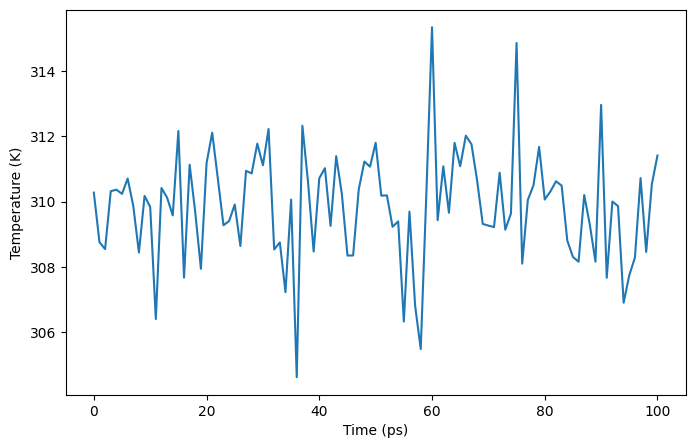

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('temperature.xvg', sep='\s+', skiprows=24, header=None)

plt.figure(figsize=(8, 5))
plt.plot(data[0], data[1])
#plt.title("")
plt.xlabel("Time (ps)")
plt.ylabel("Temperature (K)")
plt.grid(False)
plt.show()

**NPT Equilibration**

The previous step, NVT equilibration, stabilized the temperature of the system. Prior to data collection, we must also stabilize the pressure (and thus also the density) of the system. Equilibration of pressure is conducted under an NPT ensemble, wherein the Number of particles, Pressure, and Temperature are all constant. The ensemble is also called the "isothermal-isobaric" ensemble, and most closely resembles experimental conditions.

The .mdp file used for a NPT equilibration can be found in the working directory. It is not drastically different from the parameter file used for NVT equilibration, though this phase of equilibration usually takes somewhat longer than NVT equilibration because pressure takes a little longer to relax than temperature. Note the addition of the pressure coupling section, using the C-rescale barostat.

A few other changes:

* continuation = yes: We are continuing the simulation from the NVT
equilibration phase
* gen_vel = no: Velocities are read from the trajectory (see below)

We will call grompp and mdrun just as we did for NVT equilibration. Note that we are now including the -t flag to include the checkpoint file from the NVT equilibration; this file contains all the necessary state variables to continue our simulation. To conserve the velocities produced during NVT, we must include this file. The coordinate file (-c) is the final output of the NVT simulation.

In [ ]:
!gmx grompp -f npt_equili.mdp -c nvt.gro -r nvt.gro -p topol.top -o npt.tpr

                      :-) GROMACS - gmx grompp, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation
Command line:
  gmx grompp -f npt_equili.mdp -c nvt.gro -r nvt.gro -p topol.top -o npt.tpr

Ignoring obsolete mdp entry 'ns_type'
Setting the LD random seed to -33347779

Generated 2145 of the 2145 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 0.5

Generated 2145 of the 2145 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'NA'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'CL'

turning H bonds into constraints...

Taking velocities from 'nvt.gro'

NOTE 1 [file topol.top, line 18678]:
  You are combining pos

In [ ]:
!gmx mdrun -deffnm npt -nb gpu

                      :-) GROMACS - gmx mdrun, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation
Command line:
  gmx mdrun -deffnm npt -nb gpu

Reading file npt.tpr, VERSION 2026.3 (single precision)
Changing nstlist from 10 to 100, rlist from 1 to 1.172

1 GPU selected for this run.
Mapping of GPU IDs to the 2 GPU tasks in the 1 rank on this node:
  PP:0,PME:0
PP tasks will do non-perturbed short-ranged interactions on the GPU
PP task will update and constrain coordinates on the GPU
PME tasks will do all aspects on the GPU
Using 1 MPI thread
Using 2 OpenMP threads 

starting mdrun 'LYSOZYME in water'
50000 steps,    100.0 ps.

Writing final coordinates.

NOTE: 13 % of the run time was spent in pair search,
      you might want to increase nstlist (this has no effect on accuracy)

               Core t (s)   Wall t (s)        (%)
       Time:      150.037       75.022   

In [ ]:
!gmx energy -f npt.edr -o pressure.xvg

                      :-) GROMACS - gmx energy, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation
Command line:
  gmx energy -f npt.edr -o pressure.xvg

Opened npt.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  Angle            3  Proper-Dih.      4  Per.-Imp.-Dih.
  5  LJ-14            6  Coulomb-14       7  LJ-(SR)          8  Disper.-corr. 
  9  Coulomb-(SR)    10  Coul.-recip.    11  Position-Rest.  12  Potential     
 13  Kinetic-En.     14  Total-Energy    15  Conserved-En.   16  Temperature   
 17  Pres.-DC        18  Pressure        19  Constr.-rmsd    20  Box-X         
 21  Box-Y           22  Box-Z           23 

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_611/1748058662.py:4: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv('pressure.xvg', sep='\s+', skiprows=24, header=None)


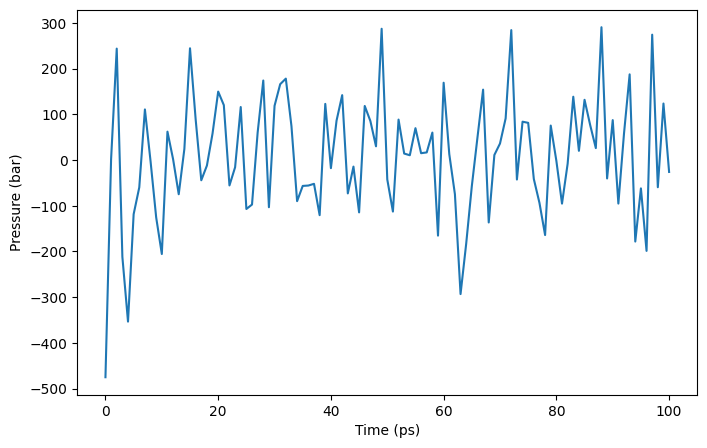

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('pressure.xvg', sep='\s+', skiprows=24, header=None)

plt.figure(figsize=(8, 5))
plt.plot(data[0], data[1])
#plt.title("")
plt.xlabel("Time (ps)")
plt.ylabel("Pressure (bar)")
plt.grid(False)
plt.show()

Production Run

In [ ]:
!gmx grompp -f production.mdp -c npt.gro -p topol.top -o production.tpr

                      :-) GROMACS - gmx grompp, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation
Command line:
  gmx grompp -f production.mdp -c npt.gro -p topol.top -o production.tpr

Ignoring obsolete mdp entry 'ns_type'
Setting the LD random seed to -87282

Generated 2145 of the 2145 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 0.5

Generated 2145 of the 2145 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'NA'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'CL'

turning H bonds into constraints...

Taking velocities from 'npt.gro'
Analysing residue names:
There are:   129    Protein residues
There 

In [ ]:
!gmx mdrun -deffnm production -nb gpu

                      :-) GROMACS - gmx mdrun, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation
Command line:
  gmx mdrun -deffnm production -nb gpu

Reading file production.tpr, VERSION 2026.3 (single precision)
Changing nstlist from 10 to 100, rlist from 1 to 1.174

1 GPU selected for this run.
Mapping of GPU IDs to the 2 GPU tasks in the 1 rank on this node:
  PP:0,PME:0
PP tasks will do non-perturbed short-ranged interactions on the GPU
PP task will update and constrain coordinates on the GPU
PME tasks will do all aspects on the GPU
Using 1 MPI thread
Using 2 OpenMP threads 

starting mdrun 'LYSOZYME in water'
5000000 steps,  10000.0 ps.


In [ ]:
!gmx trjconv -f production.xtc -o production.gro -s production.tpr -pbc whole

                     :-) GROMACS - gmx trjconv, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/BRFP_Molecular_Movies_2026/First Simulation
Command line:
  gmx trjconv -f production.xtc -o production.gro -s production.tpr -pbc whole

Note that major changes are planned in future for trjconv, to improve usability and utility.
Will write gro: Coordinate file in Gromos-87 format
Reading file production.tpr, VERSION 2026.3 (single precision)
Reading file production.tpr, VERSION 2026.3 (single precision)
Select group for output
Group     0 (         System) has 33752 elements
Group     1 (        Protein) has  1960 elements
Group     2 (      Protein-H) has  1001 elements
Group     3 (        C-alpha) has   129 elements
Group     4 (       Backbone) has   387 elements
Group     5 (      MainChain) has   517 elements
Group     6 (   MainChain+Cb) has   634 elements
Group     7 (    MainChain+H) has   646 elements
Grou

We are not really going to run the simulation in Google Colab! The next steps will be run on HPC. Please make a folder with name submission_firstsimulation_groupx and share it with Dr. Yang (yayang@caldwell.edu). Put the file npt.tpr into the folder.